In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import skew

# using scikit-learn for model building and preprocessing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

cellphone_df_path = r"C:\Users\pradi\Pradip Workspace\The IOT acadamy assignment\linear and logistic regression mobile price prediction\archive\Cellphone.csv"

In [38]:
cellphone_df = pd.read_csv(cellphone_df_path)
cellphone_df.head(5)

,Product_id,Price,Sale,weight,resoloution,ppi,cpu core,cpu freq,internal mem,ram,RearCam,Front_Cam,battery,thickness
0,203,2357,10,135.0,5.2,424,8,1.35,16.0,3.000,13.00,8.0,2610,7.4
1,880,1749,10,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9
2,40,1916,10,110.0,4.7,312,4,1.20,8.0,1.500,13.00,5.0,2000,7.6
3,99,1315,11,118.5,4.0,233,2,1.30,4.0,0.512,3.15,0.0,1400,11.0
4,880,1749,11,125.0,4.0,233,2,1.30,4.0,1.000,3.15,0.0,1700,9.9


In [39]:
cellphone_df.columns

Index(['Product_id', 'Price', 'Sale', 'weight', 'resoloution', 'ppi',
       'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam',
       'battery', 'thickness'],
      dtype='str')

In [40]:
# Understand the Data
# 1. shape of the data
cellphone_df.shape

(161, 14)

In [41]:
#2. Check column names, data types, and unique values.
cellphone_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_id    161 non-null    int64  
 1   Price         161 non-null    int64  
 2   Sale          161 non-null    int64  
 3   weight        161 non-null    float64
 4   resoloution   161 non-null    float64
 5   ppi           161 non-null    int64  
 6   cpu core      161 non-null    int64  
 7   cpu freq      161 non-null    float64
 8   internal mem  161 non-null    float64
 9   ram           161 non-null    float64
 10  RearCam       161 non-null    float64
 11  Front_Cam     161 non-null    float64
 12  battery       161 non-null    int64  
 13  thickness     161 non-null    float64
dtypes: float64(8), int64(6)
memory usage: 17.7 KB


In [14]:
# unique values in each column
"""""
for column in cellphone_df.columns:
    unique_values = cellphone_df[column].unique()
    print(f"Unique values in '{column}': {unique_values}\n")    

"""

'""\nfor column in cellphone_df.columns:\n    unique_values = cellphone_df[column].unique()\n    print(f"Unique values in \'{column}\': {unique_values}\n")    \n\n'

In [42]:
# Data Cleaning
# Handle missing values (drop, impute, or flag)
cellphone_df.isnull().sum()
# - Correct inconsistent labels (e.g., spelling errors like resoloution → resolution).
#if 'resoloution' in cellphone_df.columns:
cellphone_df.rename(columns={'resoloution': 'resolution'}, inplace=True)
""""
if 'resolution' in cellphone_df.columns:
    cellphone_df['resolution'] = cellphone_df['resolution'].replace('resoloution', 'resolution')
else:
    print("Warning: 'resolution' column not found")
"""
print("duplicate cnt is : \t" +str(cellphone_df.duplicated().sum()))

# - Identify categorical vs numerical features.
cellphone_df_categorical = cellphone_df.select_dtypes(include=['object'])
cellphone_df_numerical = cellphone_df.select_dtypes(include=['int64', 'float64'])
cellphone_df.columns

duplicate cnt is : 	0


Index(['Product_id', 'Price', 'Sale', 'weight', 'resolution', 'ppi',
       'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam',
       'battery', 'thickness'],
      dtype='str')

In [43]:
#- Convert data types if needed (e.g., strings to numeric).
cellphone_df['Price'] = pd.to_numeric(cellphone_df['Price'], errors='coerce')


Numerical features: ['Product_id', 'Price', 'Sale', 'weight', 'resolution', 'ppi', 'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam', 'battery', 'thickness']
                     mean   median          std    min     25%      50%  \
Product_id     675.559006   774.00   410.851583   10.0   237.0   774.00   
Price         2215.596273  2258.00   768.187171  614.0  1734.0  2258.00   
Sale           621.465839   106.00  1546.618517   10.0    37.0   106.00   
weight         170.426087   153.00    92.888612   66.0   134.1   153.00   
resolution       5.209938     5.15     1.509953    1.4     4.8     5.15   
ppi            335.055901   294.00   134.826659  121.0   233.0   294.00   
cpu core         4.857143     4.00     2.444016    0.0     4.0     4.00   
cpu freq         1.502832     1.40     0.599783    0.0     1.2     1.40   
internal mem    24.501714    16.00    28.804773    0.0     8.0    16.00   
ram              2.204994     2.00     1.609831    0.0     1.0     2.00 

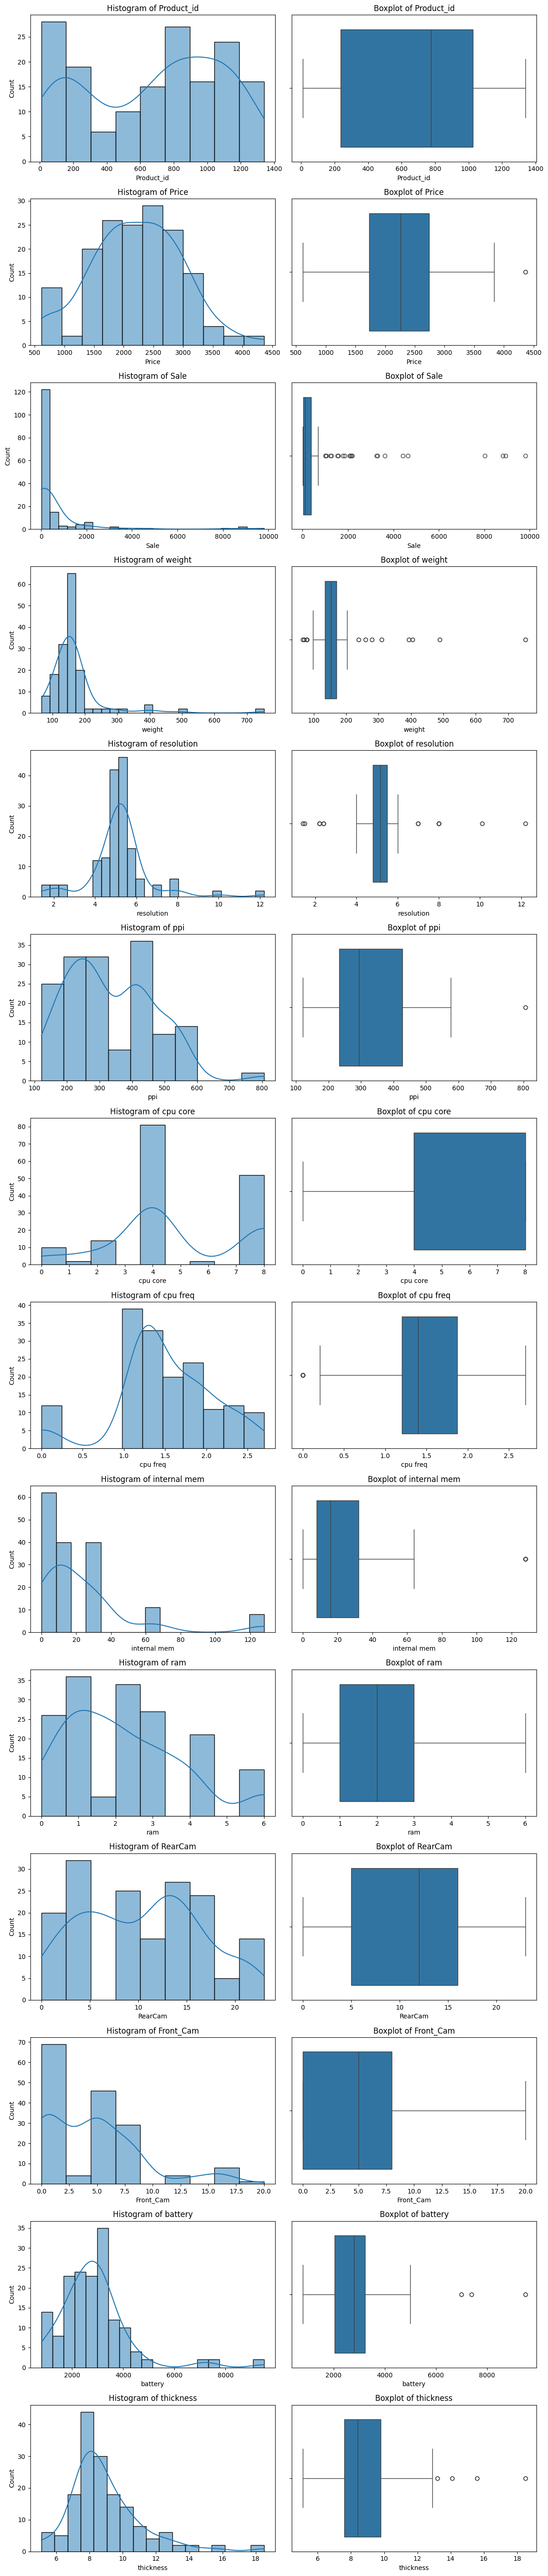

In [44]:
## Univariate Analysis
#- Explore each variable individually.
# - For numerical features: histograms, boxplots, descriptive stats (mean, median, std).


#num_cols = cellphone_df.select_dtypes(include=['int64', 'float64']).columns.tolist()
num_cols = cellphone_df_numerical.columns.to_list()
print('Numerical features:', num_cols)

# Descriptive stats
stats = cellphone_df[num_cols].describe().T
stats['median'] = cellphone_df[num_cols].median()
stats = stats[['mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max']]
print(stats)

# Histograms + boxplots
n = len(num_cols)
fig, axes = plt.subplots(n, 2, figsize=(12, 4 * n))
for i, col in enumerate(num_cols):
    sns.histplot(cellphone_df[col].dropna(), kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'Histogram of {col}')
    sns.boxplot(x=cellphone_df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()


In [45]:

# Outlier removal using IQR method
# iv.	Check/Treat the outliers and do the feature scaling if required.
""""
print('\nOutlier removal (IQR)')
original_count = len(cellphone_df)
for col in num_cols:
    q1 = cellphone_df[col].quantile(0.25)
    q3 = cellphone_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    before = len(cellphone_df)
    cellphone_df = cellphone_df[(cellphone_df[col] >= lower) & (cellphone_df[col] <= upper)]
    after = len(cellphone_df)
    diff_col_cnt = before - after
    print(f'{col}: removed {diff_col_cnt} \t{diff_col_cnt / before * 100:.2f}% rows (remaining {after}) ')
after_count = len(cellphone_df)
print(f'Total rows before {original_count}, after {after_count}')

# Update numerical DataFrame references
cellphone_df_numerical = cellphone_df[num_cols]
cellphone_df.shape


"""

'"\nprint(\'\nOutlier removal (IQR)\')\noriginal_count = len(cellphone_df)\nfor col in num_cols:\n    q1 = cellphone_df[col].quantile(0.25)\n    q3 = cellphone_df[col].quantile(0.75)\n    iqr = q3 - q1\n    lower = q1 - 1.5 * iqr\n    upper = q3 + 1.5 * iqr\n    before = len(cellphone_df)\n    cellphone_df = cellphone_df[(cellphone_df[col] >= lower) & (cellphone_df[col] <= upper)]\n    after = len(cellphone_df)\n    diff_col_cnt = before - after\n    print(f\'{col}: removed {diff_col_cnt} \t{diff_col_cnt / before * 100:.2f}% rows (remaining {after}) \')\nafter_count = len(cellphone_df)\nprint(f\'Total rows before {original_count}, after {after_count}\')\n\n# Update numerical DataFrame references\ncellphone_df_numerical = cellphone_df[num_cols]\ncellphone_df.shape\n\n\n'

In [46]:
# - For categorical features: bar plots, frequency counts.
#cat_cols = cellphone_df.select_dtypes(include=['object', 'category']).columns.tolist()
cat_cols = cellphone_df_categorical.columns.to_list()
print('Categorical features:', cat_cols)

for col in cat_cols:
    counts = cellphone_df[col].value_counts(dropna=False)
    print(f"\n{col} value counts:")
    print(counts)

    unique_values = counts.shape[0]
    if unique_values > 30:
        print(f"Skipping bar plot for {col} (too many categories: {unique_values})")
        continue

    plt.figure(figsize=(10, 4))
    sns.barplot(x=counts.index.astype(str), y=counts.values, palette='viridis')
    plt.title(f'Bar plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()



Categorical features: []


In [ ]:
# Bivariate Analysis
#- Study relationships between two variables.



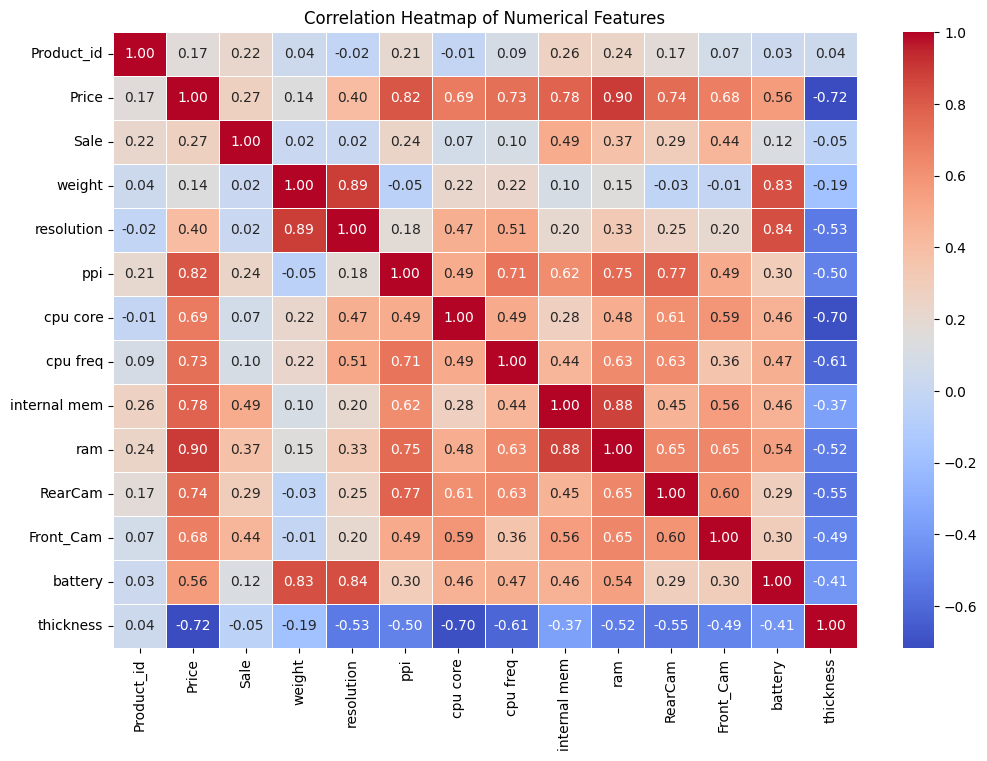

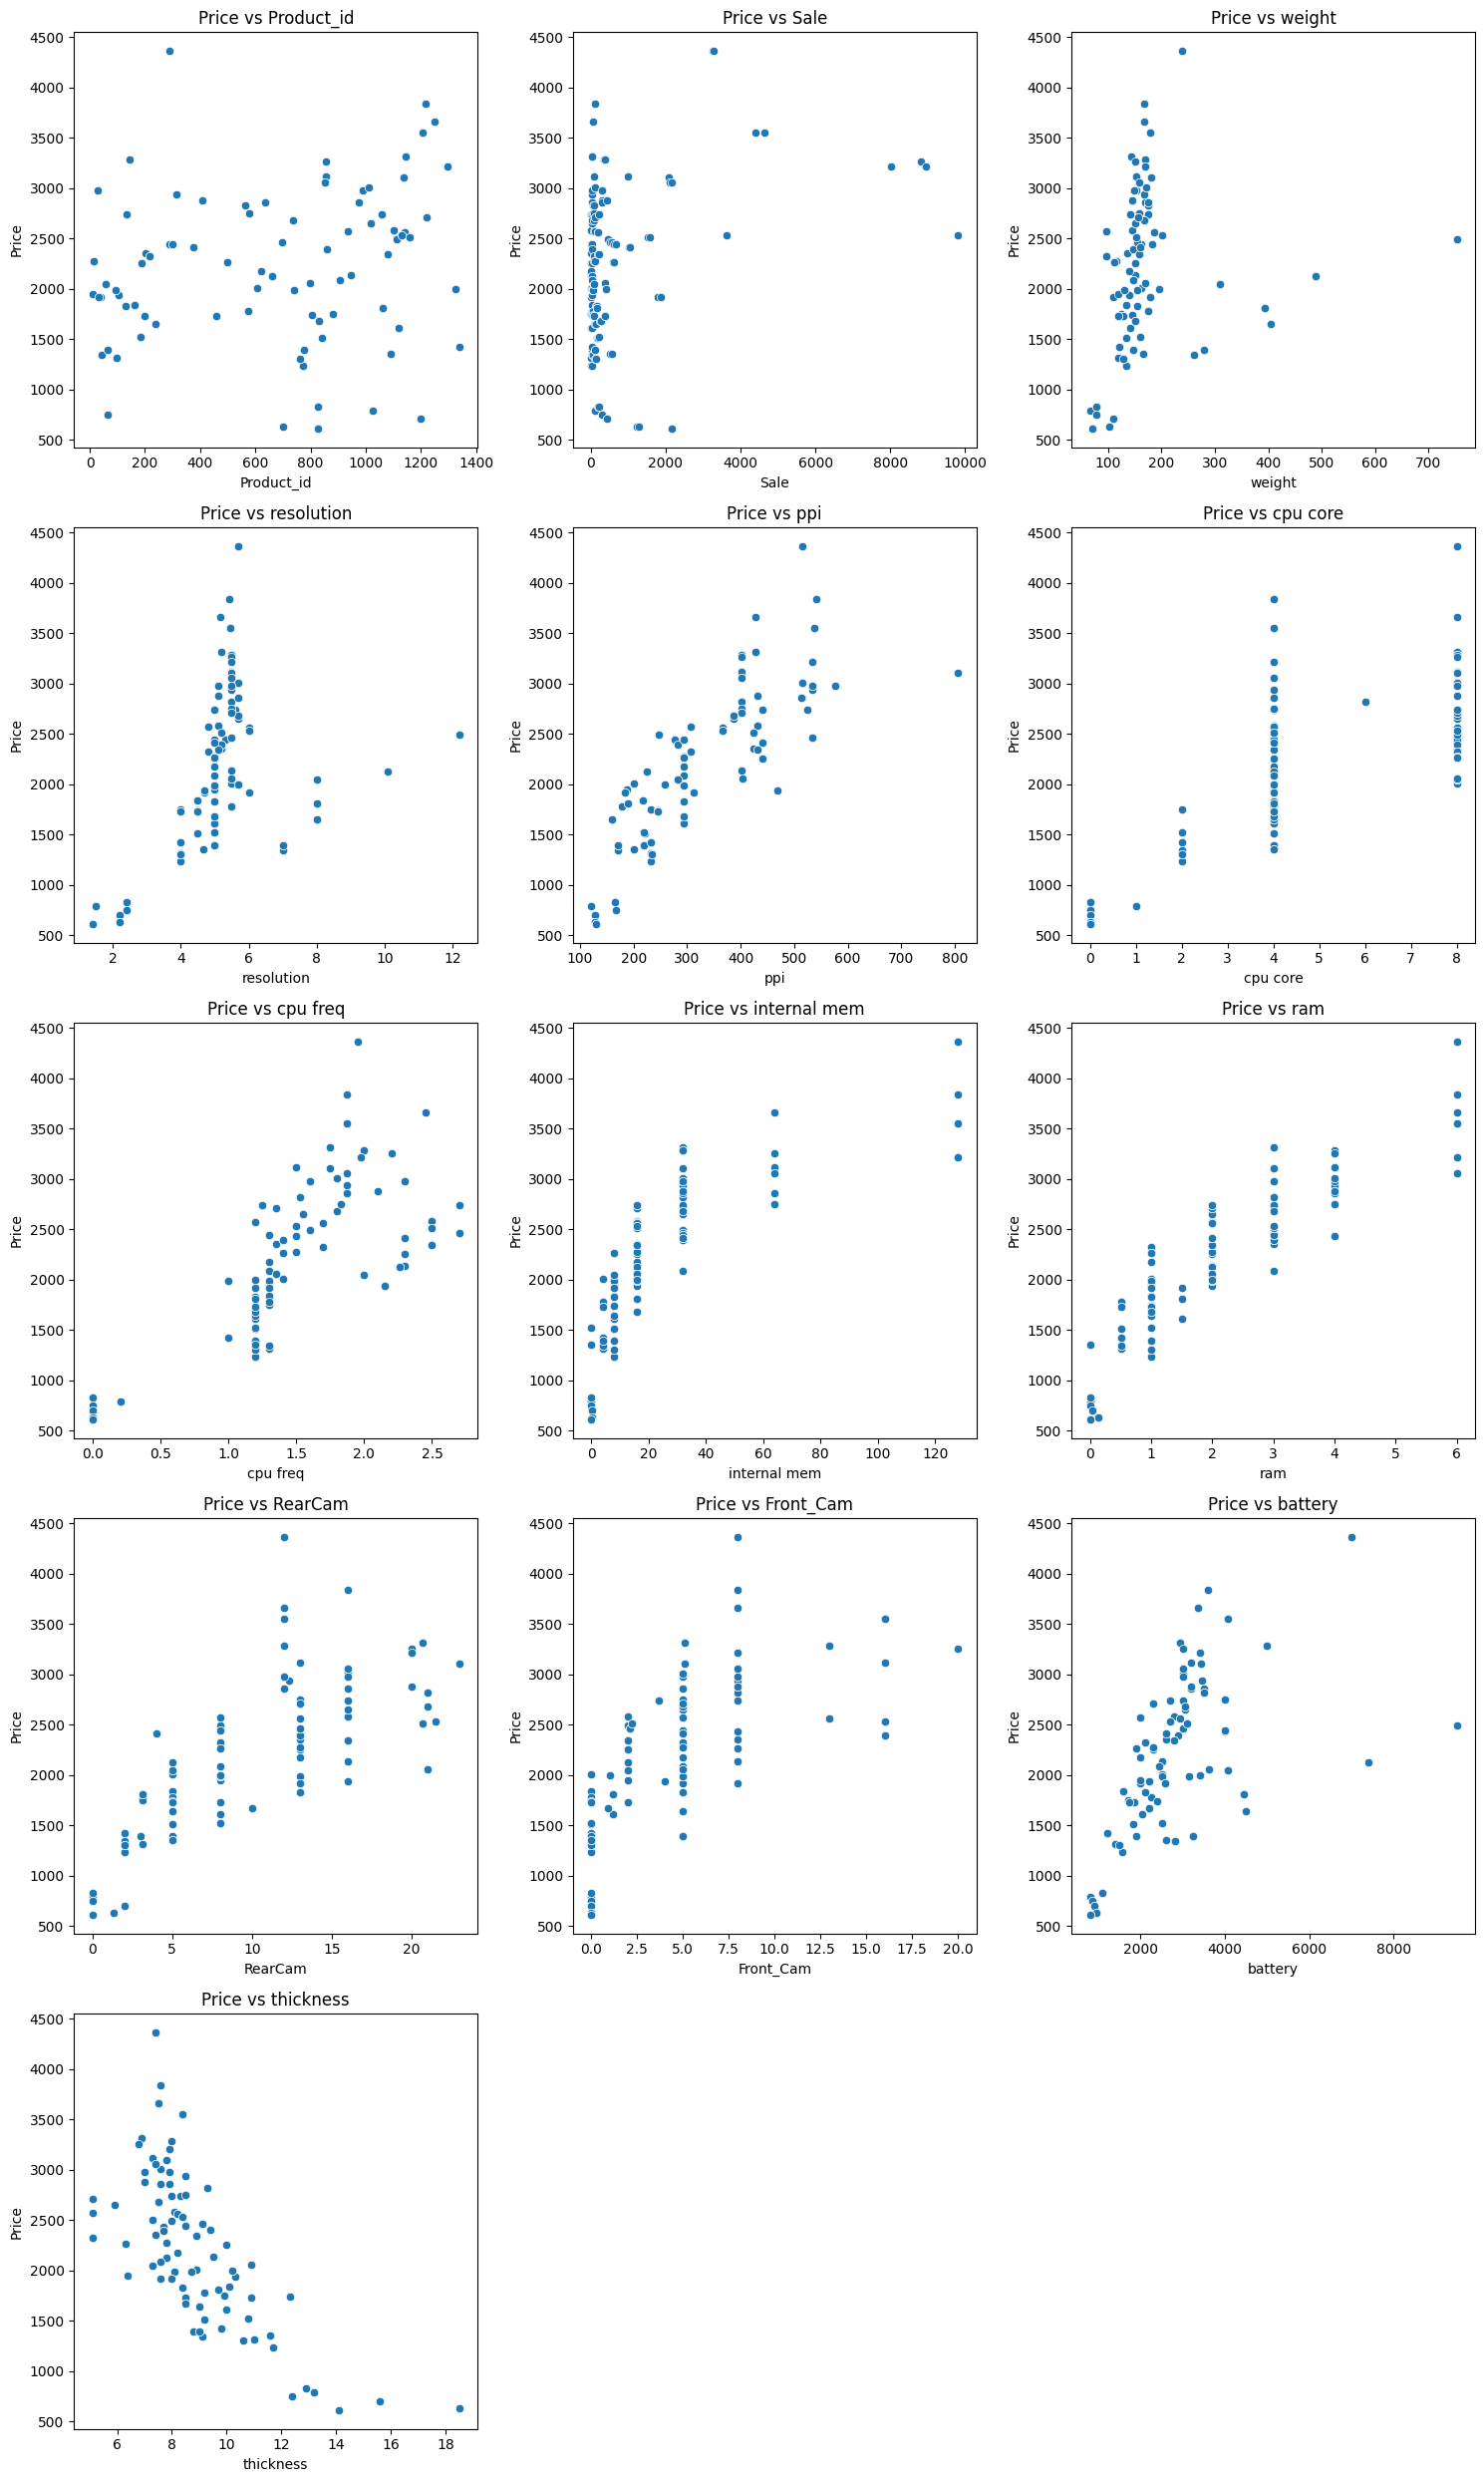

'"\nconsider corr > 0.5\n\n- product ID and sale do not have corr with any other column\n- price have corr with resolution,ram, internal memory, battery power,  camera\n- weight have corr with resolution beause high resolution thick screen and battery\n- resolution have corr with ppi, core,ram,camera,battery power\nlike wise other can understand from below graphs and corr matrix\n'

In [47]:
## Bivariate Analysis
# - Study relationships between two variables.

# Correlation matrix for numerical features
corr_matrix = cellphone_df[num_cols].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Scatter plots for Price vs each numerical feature
if 'Price' in num_cols:
    price_cols = [col for col in num_cols if col != 'Price']
    n = len(price_cols)
    fig, axes = plt.subplots((n + 2) // 3, 3, figsize=(15, 5 * ((n + 2) // 3)))
    axes = axes.flatten()
    for i, col in enumerate(price_cols):
        sns.scatterplot(x=cellphone_df[col], y=cellphone_df['Price'], ax=axes[i])
        axes[i].set_title(f'Price vs {col}')
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    plt.show()

# For categorical features, contingency tables (example for first two if any)
if len(cat_cols) >= 2:
    for i in range(len(cat_cols) - 1):
        table = pd.crosstab(cellphone_df[cat_cols[i]], cellphone_df[cat_cols[i+1]])
        print(f"\nContingency table for {cat_cols[i]} vs {cat_cols[i+1]}:")
        print(table)
        # Optional: chi-square test
        from scipy.stats import chi2_contingency
        chi2, p, dof, expected = chi2_contingency(table)
        print(f"Chi-square test: chi2={chi2:.2f}, p-value={p:.4f}")

""""
consider corr > 0.5

- product ID and sale do not have corr with any other column
- price have corr with resolution,ram, internal memory, battery power,  camera
- weight have corr with resolution beause high resolution thick screen and battery
- resolution have corr with ppi, core,ram,camera,battery power
like wise other can understand from below graphs and corr matrix
"""

Skewness for numerical variables:
Sale            1.631423
internal mem    1.285026
cpu freq        1.044277
ram             0.736599
cpu core        0.447864
ppi             0.396369
battery         0.191449
Price           0.191330
RearCam         0.113556
Front_Cam       0.010298
thickness      -0.058406
Product_id     -0.099815
weight         -0.344597
resolution     -0.663587
dtype: float64

Features with abs(skewness) > 0.75 : ['Sale', 'cpu freq', 'internal mem']
Transformed Sale → Sale_log1p
Transformed cpu freq → cpu freq_log1p
Transformed internal mem → internal mem_log1p


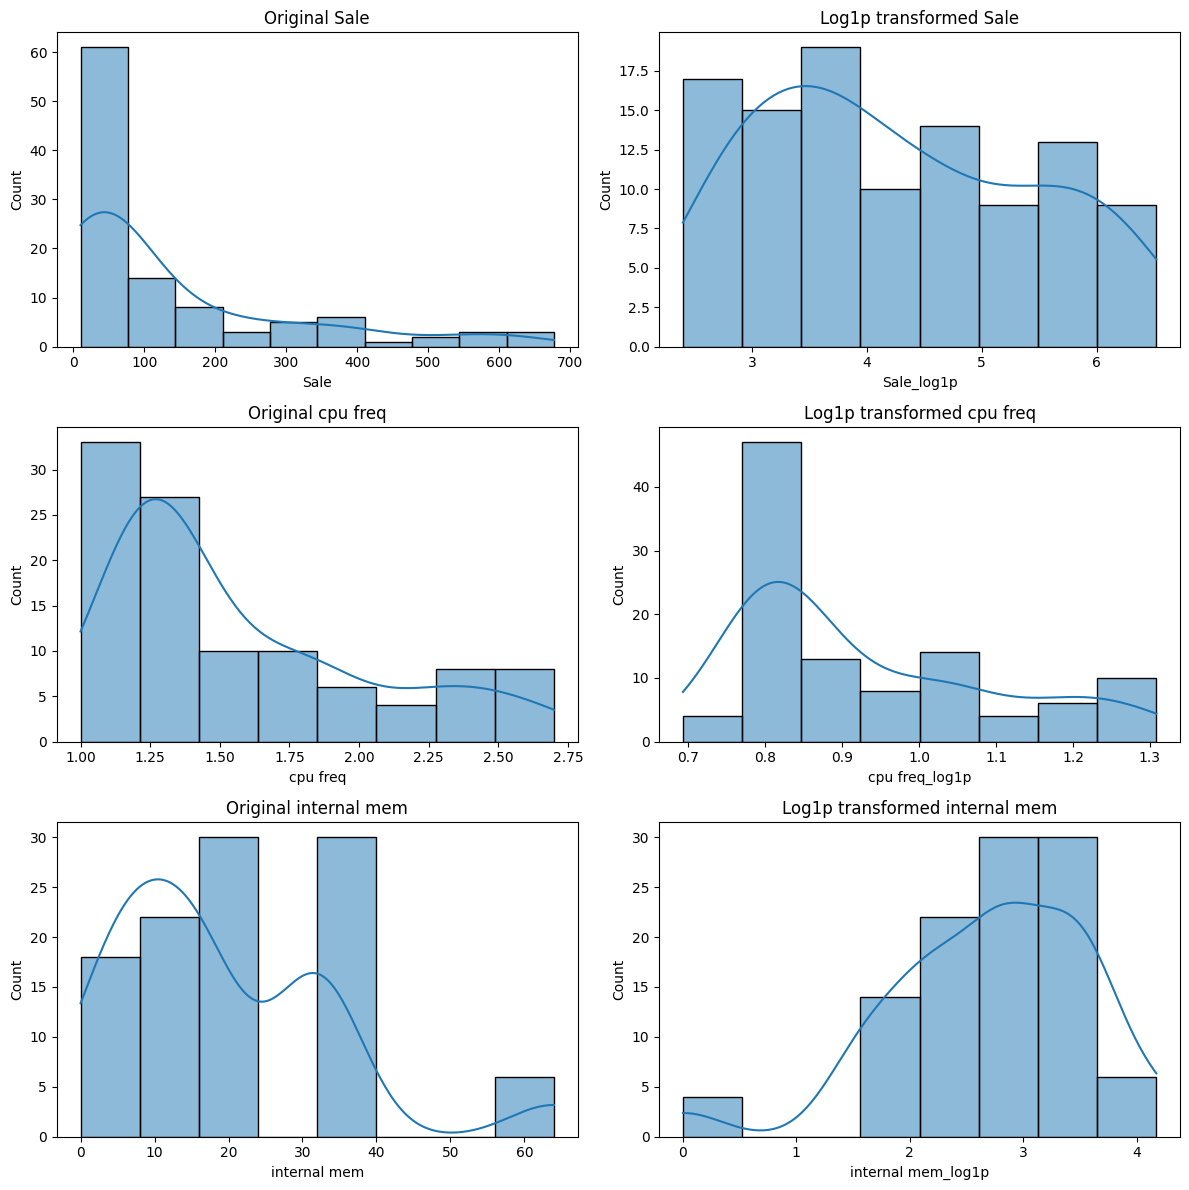

In [28]:
# iii. Check the distributions/skewness in the variables and do the transformations if required.


# Evaluate skewness for numerical variables
skewness = cellphone_df[num_cols].skew()
print('Skewness for numerical variables:')
print(skewness.sort_values(ascending=False))

# Select skewed features
skew_threshold = 0.75
skewed_cols = skewness[skewness.abs() > skew_threshold].index.tolist()
print('\nFeatures with abs(skewness) >', skew_threshold, ':', skewed_cols)

# Apply log1p transformation for positively skewed and non-negative variables
transformed_cols = []
for col in skewed_cols:
    if (cellphone_df[col] >= 0).all():
        transformed_name = f'{col}_log1p'
        cellphone_df[transformed_name] = np.log1p(cellphone_df[col])
        transformed_cols.append(transformed_name)
        print(f'Transformed {col} → {transformed_name}')
    else:
        print(f'Skipping log transform for {col} because it contains negative values')

# Compare distributions before and after transformation
compare_cols = [col for col in skewed_cols if f'{col}_log1p' in cellphone_df.columns]
if compare_cols:
    fig, axes = plt.subplots(len(compare_cols), 2, figsize=(12, 4 * len(compare_cols)))
    for i, col in enumerate(compare_cols):
        sns.histplot(cellphone_df[col].dropna(), kde=True, ax=axes[i, 0])
        axes[i, 0].set_title(f'Original {col}')
        sns.histplot(cellphone_df[f'{col}_log1p'].dropna(), kde=True, ax=axes[i, 1])
        axes[i, 1].set_title(f'Log1p transformed {col}')
    plt.tight_layout()
    plt.show()
else:
    print('No numeric features were transformed.')


In [52]:
# v. Create a ML model to predict the price of the phone based on the specifications given.
# use linear regression for numerical features and logistic regression for categorical features (if any)


# Prepare numerical features and target
feature_cols = []
for col in num_cols:
    if col == 'Price':
        continue
    transformed_col = f'{col}_log1p'
    if transformed_col in cellphone_df.columns:
        feature_cols.append(transformed_col)
    else:
        feature_cols.append(col)

print('Using features:', feature_cols)
X = cellphone_df[feature_cols]
y = cellphone_df['Price']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and evaluate linear regression
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred_test = model.predict(X_test_scaled)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_pred_test)
accuracy_test = np.mean(np.abs(y_test - y_pred_test) <= 0.1 * np.maximum(np.abs(y_test), 1))

y_pred_train = model.predict(X_train_scaled)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_pred_train)
accuracy_train = np.mean(np.abs(y_train - y_pred_train) <= 0.1 * np.maximum(np.abs(y_train), 1))

print(f'Linear Regression results test:')
print(f'  RMSE: {rmse_test:.2f}')
print(f'  R^2: {r2_test:.3f}')
print(f'  Accuracy (within 10%): {accuracy_test:.2%}')

print(f'Linear Regression results train:')
print(f'  RMSE: {rmse_train:.2f}')
print(f'  R^2: {r2_train:.3f}')
print(f'  Accuracy (within 10%): {accuracy_train:.2%}')




# Coefficients
coeff_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model.coef_
}).sort_values(by='coefficient', key=lambda s: s.abs(), ascending=False)
print('\nFeature coefficients:')
print(coeff_df)


Using features: ['Product_id', 'Sale', 'weight', 'resolution', 'ppi', 'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam', 'battery', 'thickness']
Linear Regression results test:
  RMSE: 151.86
  R^2: 0.959
  Accuracy (within 10%): 78.79%
Linear Regression results train:
  RMSE: 168.09
  R^2: 0.952
  Accuracy (within 10%): 69.53%

Feature coefficients:
         feature  coefficient
11       battery   177.871360
8            ram   162.089051
12     thickness  -161.445927
7   internal mem   154.596192
4            ppi   153.179805
5       cpu core   121.766815
3     resolution   -75.996275
2         weight   -75.516458
6       cpu freq    73.324846
10     Front_Cam    34.067809
1           Sale   -30.833158
0     Product_id    22.047904
9        RearCam    16.088193


In [ ]:
""""
result with outlire deleted

Using features: ['Product_id', 'Sale_log1p', 'weight', 'resolution', 'ppi', 'cpu core', 'cpu freq_log1p', 'internal mem_log1p', 'ram', 'RearCam', 'Front_Cam', 'battery', 'thickness']
Linear Regression results test:
  RMSE: 236.01
  R^2: 0.795
  Accuracy (within 10%): 63.64%
Linear Regression results train:
  RMSE: 158.03
  R^2: 0.926
  Accuracy (within 10%): 79.76%

Feature coefficients:
               feature  coefficient
8                  ram   214.399280
12           thickness  -192.887425
4                  ppi   145.925349
5             cpu core   141.412493
11             battery   111.290023
3           resolution  -103.267731
2               weight    63.998811
6       cpu freq_log1p    60.737733
7   internal mem_log1p   -51.603986
1           Sale_log1p   -23.012883
10           Front_Cam   -20.758452
9              RearCam    18.617615
0           Product_id     8.822161

"""

"""
without outlier removal

Using features: ['Product_id', 'Sale', 'weight', 'resolution', 'ppi', 'cpu core', 'cpu freq', 'internal mem', 'ram', 'RearCam', 'Front_Cam', 'battery', 'thickness']
Linear Regression results test:
  RMSE: 151.86
  R^2: 0.959
  Accuracy (within 10%): 78.79%
Linear Regression results train:
  RMSE: 168.09
  R^2: 0.952
  Accuracy (within 10%): 69.53%

Feature coefficients:
         feature  coefficient
11       battery   177.871360
8            ram   162.089051
12     thickness  -161.445927
7   internal mem   154.596192
4            ppi   153.179805
5       cpu core   121.766815
3     resolution   -75.996275
2         weight   -75.516458
6       cpu freq    73.324846
10     Front_Cam    34.067809
1           Sale   -30.833158
0     Product_id    22.047904
9        RearCam    16.088193

"""


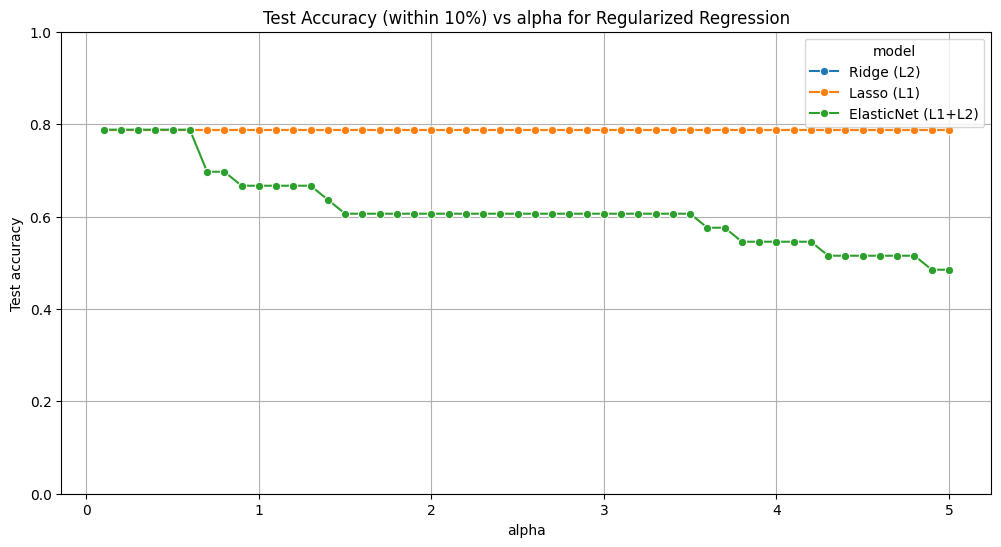

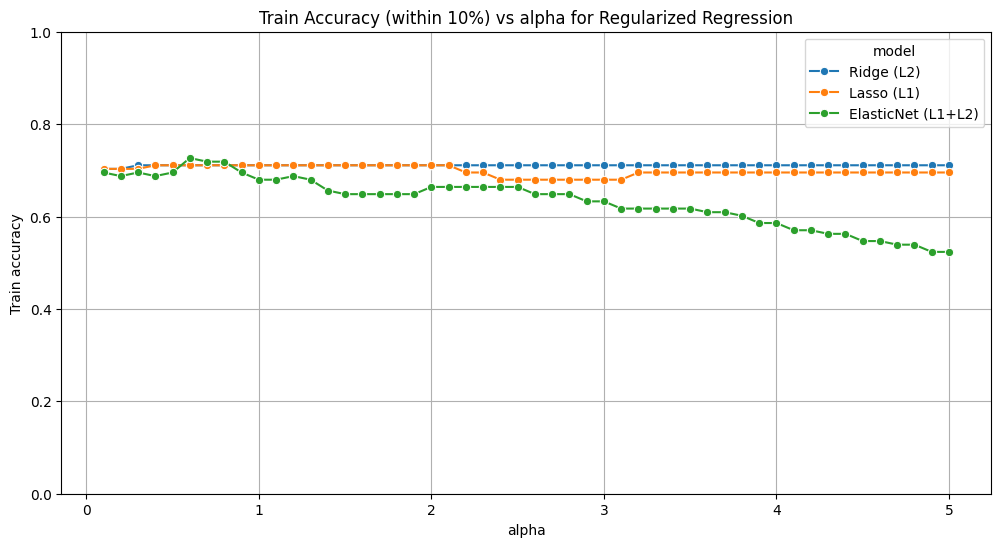

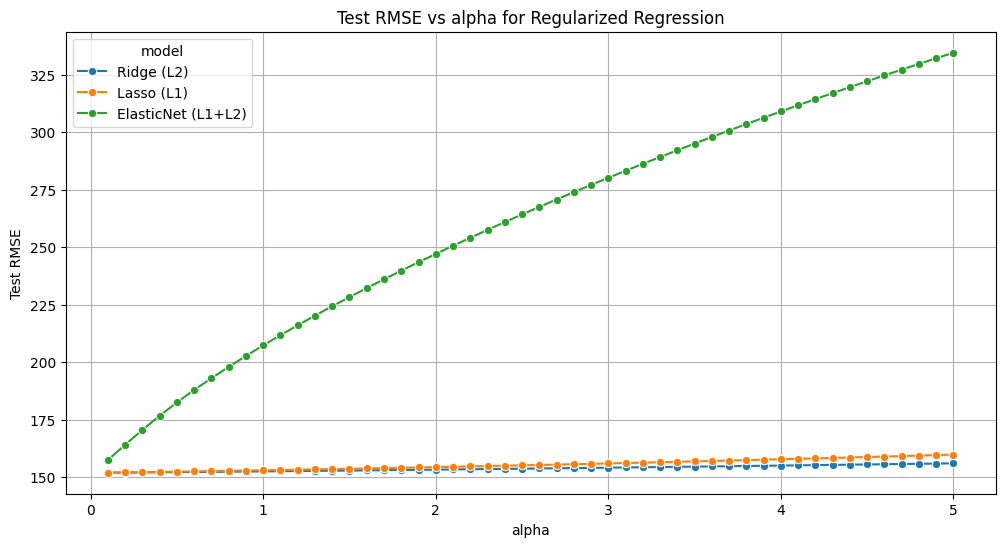


Best alpha by test accuracy:
             model  alpha  accuracy_test  rmse_test  r2_test
ElasticNet (L1+L2)    0.1       0.787879 157.449595 0.956269
        Lasso (L1)    0.1       0.787879 151.981237 0.959254
        Ridge (L2)    0.1       0.787879 151.918371 0.959288

Summary of best alpha values:
             model  alpha  accuracy_test  rmse_test  r2_test
ElasticNet (L1+L2)    0.1       0.787879 157.449595 0.956269
        Lasso (L1)    0.1       0.787879 151.981237 0.959254
        Ridge (L2)    0.1       0.787879 151.918371 0.959288


In [55]:
# perform l1, l2, elastic net regression across alpha values
from sklearn.linear_model import Ridge, Lasso, ElasticNet

alphas = np.arange(0.1, 5.1, 0.1)
models = [
    ('Ridge (L2)', Ridge),
    ('Lasso (L1)', Lasso),
    ('ElasticNet (L1+L2)', ElasticNet)
]

results = []
for model_name, ModelClass in models:
    for alpha in alphas:
        if model_name == 'ElasticNet (L1+L2)':
            model_inst = ModelClass(alpha=alpha, l1_ratio=0.5, max_iter=10000)
        else:
            model_inst = ModelClass(alpha=alpha, max_iter=10000)
        model_inst.fit(X_train_scaled, y_train)

        y_pred_test = model_inst.predict(X_test_scaled)
        y_pred_train = model_inst.predict(X_train_scaled)
        mse_test = mean_squared_error(y_test, y_pred_test)
        mse_train = mean_squared_error(y_train, y_pred_train)

        accuracy_test = np.mean(np.abs(y_test - y_pred_test) <= 0.1 * np.maximum(np.abs(y_test), 1))
        accuracy_train = np.mean(np.abs(y_train - y_pred_train) <= 0.1 * np.maximum(np.abs(y_train), 1))

        results.append({
            'model': model_name,
            'alpha': alpha,
            'rmse_test': np.sqrt(mse_test),
            'rmse_train': np.sqrt(mse_train),
            'r2_test': r2_score(y_test, y_pred_test),
            'r2_train': r2_score(y_train, y_pred_train),
            'accuracy_test': accuracy_test,
            'accuracy_train': accuracy_train
        })

results_df = pd.DataFrame(results)

# Plot accuracy vs alpha for each model
plt.figure(figsize=(12, 6))
sns.lineplot(data=results_df, x='alpha', y='accuracy_test', hue='model', marker='o')
plt.title('Test Accuracy (within 10%) vs alpha for Regularized Regression')
plt.xlabel('alpha')
plt.ylabel('Test accuracy')
plt.ylim(0, 1)
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
sns.lineplot(data=results_df, x='alpha', y='accuracy_train', hue='model', marker='o')
plt.title('Train Accuracy (within 10%) vs alpha for Regularized Regression')
plt.xlabel('alpha')
plt.ylabel('Train accuracy')
plt.ylim(0, 1)
plt.grid(True)
plt.show()

# Plot RMSE vs alpha for additional comparison
plt.figure(figsize=(12, 6))
sns.lineplot(data=results_df, x='alpha', y='rmse_test', hue='model', marker='o')
plt.title('Test RMSE vs alpha for Regularized Regression')
plt.xlabel('alpha')
plt.ylabel('Test RMSE')
plt.grid(True)
plt.show()

# Best alpha by test accuracy for each model

if 'model' in results_df.columns and not results_df.empty:
    # Get the row indices of max accuracy for each model
    max_indices = results_df.groupby('model')['accuracy_test'].idxmax()
    best_alpha = results_df.loc[max_indices.values]
    print('\nBest alpha by test accuracy:')
    print(best_alpha[['model', 'alpha', 'accuracy_test', 'rmse_test', 'r2_test']].to_string(index=False))

    # Use the best alpha values to print a concise summary
    summary_df = results_df.groupby('model').apply(lambda df: df.loc[df['accuracy_test'].idxmax()])
    summary_df = summary_df.reset_index(drop=False)[['model', 'alpha', 'accuracy_test', 'rmse_test', 'r2_test']]
    print('\nSummary of best alpha values:')
    print(summary_df.to_string(index=False))
else:
    print('Unable to summarize best alpha values: results_df is empty or missing the model column.')
    print('results_df columns:', results_df.columns.tolist())
    print('results_df length:', len(results_df))
